In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import h5py

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    horizontal_flip=True,   # ảnh lật ngang
    zoom_range=0.1,         # phóng to/thu nhỏ
    brightness_range=[0.8,1.2]
)

In [6]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [7]:
im_size = 224
batch_size = 128

!unzip "/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/datasets/100-vietnamese-food.zip" \
  -d "/content/vietnamese_food"

Streaming output truncated to the last 5000 lines.
  inflating: /content/vietnamese_food/images/mam_chung/image_163.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_164.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_165.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_166.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_167.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_168.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_169.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_17.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_170.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_171.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_172.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_173.jpg  
  inflating: /content/vietnamese_food/images/mam_chung/image_174.jpg  
  inflating: /content/vietn

In [8]:
BASE_DIR = "/content/vietnamese_food/images"

In [9]:


train_generator = datagen.flow_from_directory(
    directory=f"{BASE_DIR}",
    target_size=(im_size, im_size),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

Found 14538 images belonging to 100 classes.


In [10]:
valid_generator = datagen.flow_from_directory(
    BASE_DIR,
    target_size=(im_size, im_size),
    color_mode="rgb",
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 6162 images belonging to 100 classes.


In [11]:
STEP_SIZE_TRAIN=train_generator.n//train_generator.batch_size
STEP_SIZE_VALID=valid_generator.n//valid_generator.batch_size

In [12]:
for image in train_generator:
  print(type(image))
  print(type(image[0]))
  print(image[0].shape)
  break

<class 'tuple'>
<class 'numpy.ndarray'>
(128, 224, 224, 3)


In [13]:
image[0].shape

(128, 224, 224, 3)

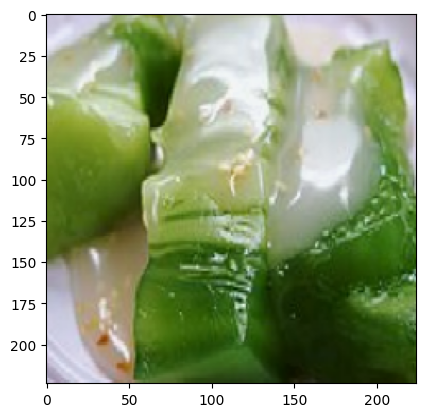

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(image[0][0])

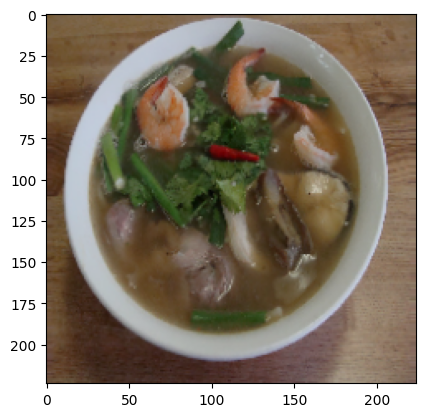

In [15]:
plt.imshow(image[0][5])

In [16]:
CLASSES = train_generator.num_classes
INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 15
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS
FINE_TUNE_AT = 516

In [17]:
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

pretrained_model = ResNet50V2(weights='imagenet', include_top=False)
last_output = pretrained_model.output
x = GlobalAveragePooling2D()(last_output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(CLASSES, activation='softmax')(x)
model = Model(inputs=pretrained_model.input, outputs=outputs)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
base_checkpointer = ModelCheckpoint(
    filepath = '/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5',
    save_best_only = True,
    verbose = 1
)

fine_tune_checkpointer = ModelCheckpoint(
    filepath = '/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/fine_tune_model_best.h5',
    save_best_only = True,
    verbose = 1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    verbose=1,
    mode='min',
    min_lr=1e-6,
)

# Stop if no improvement after 3 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

In [19]:
for layer in pretrained_model.layers: layer.trainable = False
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
history = model.fit(
    train_generator,
    validation_data = valid_generator,
    validation_steps = valid_generator.n // batch_size,
    steps_per_epoch = train_generator.n // batch_size,
    callbacks = [base_checkpointer, reduce_lr],
    epochs = 15,
    verbose = 1,
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2968 - loss: 2.9717
Epoch 1: val_loss improved from inf to 1.91563, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.2974 - loss: 2.9682 - val_accuracy: 0.5063 - val_loss: 1.9156 - learning_rate: 0.0010
Epoch 2/15
  1/113 ━━━━━━━━━━━━━━━━━━━━ 31s 277ms/step - accuracy: 0.5312 - loss: 1.8941

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 1.91563 to 1.88434, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 112s 1000ms/step - accuracy: 0.5312 - loss: 1.8941 - val_accuracy: 0.5146 - val_loss: 1.8843 - learning_rate: 0.0010
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5455 - loss: 1.7320
Epoch 3: val_loss improved from 1.88434 to 1.69716, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


...

113/113 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 0.6786 - loss: 1.1437 - val_accuracy: 0.6061 - val_loss: 1.5384 - learning_rate: 0.0010
Epoch 8/15
  1/113 ━━━━━━━━━━━━━━━━━━━━ 30s 275ms/step - accuracy: 0.6562 - loss: 1.3312
Epoch 8: val_loss did not improve from 1.53843
113/113 ━━━━━━━━━━━━━━━━━━━━ 109s 970ms/step - accuracy: 0.6562 - loss: 1.3312 - val_accuracy: 0.5921 - val_loss: 1.5564 - learning_rate: 0.0010
Epoch 9/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7281 - loss: 0.9531
Epoch 9: val_loss did not improve from 1.53843
113/113 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.7280 - loss: 0.9534 - val_accuracy: 0.5924 - val_loss: 1.5544 - learning_rate: 0.0010
Epoch 10/15
  1/113 ━━━━━━━━━━━━━━━━━━━━ 29s 266ms/step - accuracy: 0.7500 - loss: 0.9318
Epoch 10: val_loss improved from 1.53843 to 1.52575, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 110s 980ms/step - accuracy: 0.7500 - loss: 0.9318 - val_accuracy: 0.6021 - val_loss: 1.5258 - learning_rate: 0.0010
Epoch 11/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7602 - loss: 0.8291
Epoch 11: val_loss improved from 1.52575 to 1.52353, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.7601 - loss: 0.8293 - val_accuracy: 0.6191 - val_loss: 1.5235 - learning_rate: 0.0010
Epoch 12/15
  1/113 ━━━━━━━━━━━━━━━━━━━━ 34s 311ms/step - accuracy: 0.7422 - loss: 0.8740
Epoch 12: val_loss improved from 1.52353 to 1.50449, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7422 - loss: 0.8740 - val_accuracy: 0.6183 - val_loss: 1.5045 - learning_rate: 0.0010
Epoch 13/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7880 - loss: 0.7250
Epoch 13: val_loss did not improve from 1.50449
113/113 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.7879 - loss: 0.7253 - val_accuracy: 0.6191 - val_loss: 1.5376 - learning_rate: 0.0010
Epoch 14/15
  1/113 ━━━━━━━━━━━━━━━━━━━━ 30s 276ms/step - accuracy: 0.7578 - loss: 0.8515
Epoch 14: val_loss improved from 1.50449 to 1.49297, saving model to /content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/base_model_best.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 110s 984ms/step - accuracy: 0.7578 - loss: 0.8515 - val_accuracy: 0.6284 - val_loss: 1.4930 - learning_rate: 0.0010
Epoch 15/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8123 - loss: 0.6295
Epoch 15: val_loss did not improve from 1.49297
113/113 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step - accuracy: 0.8123 - loss: 0.6299 - val_accuracy: 0.6128 - val_loss: 1.5129 - learning_rate: 0.0010


In [22]:
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

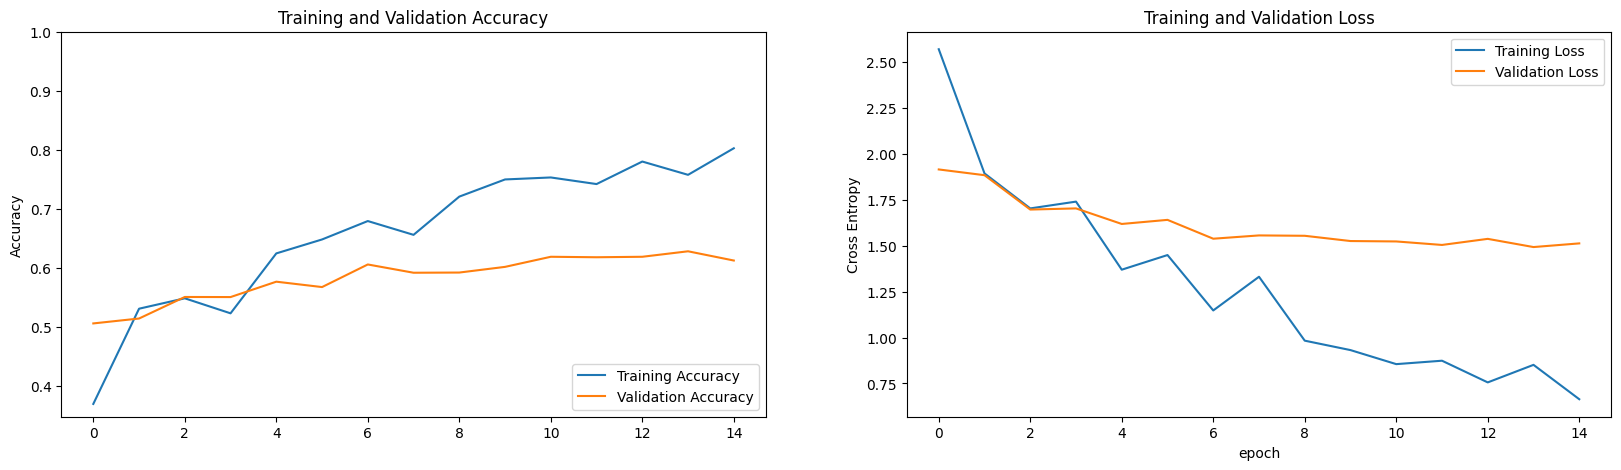

In [23]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()), 1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([min(plt.ylim()), max(plt.ylim())])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
# plt.savefig(BASE_MODEL_FIG)
plt.show()

In [25]:
model.save('/content/drive/MyDrive/Thuc_tap_tot_nghiep/Food-image-recognition-using-machine-learning-classifier/ML_models/Resnet50.h5')

In [ ]:
print('-Training set-\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

In [ ]:
import numpy as np

labels = np.array(list(train_generator.class_indices.keys()))
print("Labels:", labels)

Labels: ['baba_nau_chuoi_dau' 'banh tet' 'banh_bao' 'banh_beo' 'banh_bo'
 'banh_bot_loc' 'banh_can' 'banh_canh' 'banh_chung' 'banh_cong'
 'banh_cuon' 'banh_da_cua' 'banh_da_lon' 'banh_duc' 'banh_gai' 'banh_giay'
 'banh_gio' 'banh_khot' 'banh_la' 'banh_mi' 'banh_pia' 'banh_tai_heo'
 'banh_tieu' 'banh_tom_ho_tay' 'banh_trang_nuong' 'banh_troi_nuoc'
 'banh_trung_thu' 'banh_u' 'banh_xeo' 'bo_kho' 'bo_luc_lac' 'bo_ne'
 'bo_nuong_la_lot' 'bun_bo_hue' 'bun_cha' 'bun_cha_ca' 'bun_dau_mam_tom'
 'bun_mam' 'bun_rieu' 'bun_thit_nuong' 'ca_kho_to' 'ca_loc_nuong'
 'ca_muoi_xoi' 'ca_ri_ga' 'ca_sot_ca_chua' 'canh_bi_do' 'canh_chua'
 'canh_cua' 'canh_kho_hoa' 'canh_khoai_tim' 'cao_lau' 'cha_ca_la_vong'
 'cha_com' 'cha_lui' 'chao_long' 'chao_vit' 'com_chay_cha_bong'
 'com_chien' 'com_ga_xoi_mo' 'com_lam' 'com_rang_dua_bo' 'com_tam'
 'cua_hap_bia' 'cut_lon_xao_me' 'ga_chien_nuoc_mam' 'ga_hap_la_chanh'
 'goi_ca_chich' 'goi_cuon' 'hu_tieu' 'khau_nhuc' 'kho_muc_nuong'
 'kho_quet' 'lap_xuong' 'luon_om_chuoi_